# DeepLense Test 5 - Lens vs Non-Lens Classification (v3 - Corrected)

This notebook is a direct notebook conversion of the latest `v3` script version.
The training logic and configuration are kept unchanged; only the script is split into logical notebook cells for readability and reruns.

## Strategy
1. Keep the original custom ResNet that already performs strongly on this task.
2. Extend early stopping and scheduler patience.
3. Keep batch size 256 and `ReduceLROnPlateau`.
4. Add optional focal loss, label smoothing, Mixup, and batched D4 TTA.
5. Report ROC/AUROC as the official metric, with AP as supplementary.


In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

plt.style.use("seaborn-v0_8-whitegrid")

# -- Config -------------------------------------------------------------------
SEED                 = 42
VAL_SIZE             = 0.10
BATCH_SIZE           = 256
EPOCHS               = 50
LR                   = 3e-4
WEIGHT_DECAY         = 1e-4

EARLY_STOP_PATIENCE  = 15
SCHEDULER_PATIENCE   = 4

LABEL_SMOOTHING      = 0.05
MIXUP_ALPHA          = 0.2
USE_FOCAL_LOSS       = False

NUM_WORKERS          = 8 if torch.cuda.is_available() else 0
BEST_MODEL_PATH      = "best_model_v3.pt"


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

cwd       = Path.cwd()
ROOT      = cwd if (cwd / "dataset").exists() else cwd / "test5"
DATA_ROOT = ROOT / "dataset"
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

print(f"Device    : {device}")
print(f"Data root : {DATA_ROOT}")
print(f"Artifacts : {ARTIFACTS}")


Device    : cuda
Data root : /home/colin/gsoc26-deeplense/test5/dataset
Artifacts : /home/colin/gsoc26-deeplense/test5/artifacts


## Data Loading And Split

Load the `.npy` files, create train/validation/test splits, and print split statistics.

In [2]:
def load_class(folder_name, label):
    paths = sorted((DATA_ROOT / folder_name).glob("*.npy"))
    if not paths:
        raise FileNotFoundError(f"No .npy files in {DATA_ROOT / folder_name}")
    return [(str(p), label) for p in paths]


train_data = load_class("train_nonlenses", 0) + load_class("train_lenses", 1)
test_data  = load_class("test_nonlenses",  0) + load_class("test_lenses",  1)

train_paths, train_labels = zip(*train_data)
test_paths,  test_labels  = zip(*test_data)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    list(train_paths), list(train_labels),
    test_size=VAL_SIZE, stratify=train_labels, random_state=SEED,
)

stats = pd.DataFrame([
    {"split": "train", "samples": len(train_labels), "positives": int(sum(train_labels))},
    {"split": "val",   "samples": len(val_labels),   "positives": int(sum(val_labels))},
    {"split": "test",  "samples": len(test_labels),  "positives": int(sum(test_labels))},
])
stats["negatives"] = stats["samples"] - stats["positives"]
stats["pos_frac"]  = (stats["positives"] / stats["samples"]).round(4)
print("\nData split:")
print(stats.to_string(index=False))



Data split:
split  samples  positives  negatives  pos_frac
train    27364       1557      25807    0.0569
  val     3041        173       2868    0.0569
 test    19650        195      19455    0.0099


## Normalization Statistics

Compute or load channel-wise normalization statistics from the training split.

In [3]:
norm_path = ARTIFACTS / "norm_stats.npz"
if norm_path.exists():
    d    = np.load(norm_path)
    mean, std = d["mean"], d["std"]
    print(f"\nNorm stats loaded from {norm_path}")
else:
    ch_sum, ch_sq, n_pix = np.zeros(3), np.zeros(3), 0
    for p in train_paths:
        img   = np.load(p).astype(np.float32)
        flat  = img.reshape(3, -1)
        ch_sum += flat.sum(1)
        ch_sq  += (flat ** 2).sum(1)
        n_pix  += flat.shape[1]
    mean = ch_sum / n_pix
    std  = np.sqrt(ch_sq / n_pix - mean ** 2)
    np.savez(norm_path, mean=mean, std=std)
    print(f"\nNorm stats saved to {norm_path}")

print(f"Mean: {mean}  Std: {std}")



Norm stats loaded from /home/colin/gsoc26-deeplense/test5/artifacts/norm_stats.npz
Mean: [0.27442211 0.1917139  0.1053785 ]  Std: [0.17398128 0.15529123 0.11290807]


## Dataset And DataLoaders

Define dataset wrappers, augmentations, and loaders for train/validation/test.

In [4]:
class LensDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img   = torch.from_numpy(np.load(self.paths[idx]).astype(np.float32))
        if self.transform is not None:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label


class RandomRotate90:
    def __call__(self, img):
        k = torch.randint(0, 4, ()).item()
        return torch.rot90(img, k, dims=(-2, -1))


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    RandomRotate90(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])
eval_transform = transforms.Normalize(mean.tolist(), std.tolist())

train_loader = DataLoader(
    LensDataset(train_paths, train_labels, train_transform),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
val_loader = DataLoader(
    LensDataset(val_paths, val_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)
test_loader = DataLoader(
    LensDataset(test_paths, test_labels, eval_transform),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory,
)


## Model Definition

Keep the original custom residual CNN architecture unchanged.

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
            if stride != 1 or in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        out = F.silu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.silu(out + self.shortcut(x))


class LensBinaryResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.SiLU(),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32,  32),           ResidualBlock(32,  32))
        self.layer2 = nn.Sequential(ResidualBlock(32,  64, stride=2), ResidualBlock(64,  64))
        self.layer3 = nn.Sequential(ResidualBlock(64,  128, stride=2),ResidualBlock(128, 128))
        self.layer4 = nn.Sequential(ResidualBlock(128, 256, stride=2),ResidualBlock(256, 256))
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.head   = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 1))

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)


model = LensBinaryResNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: custom ResNet  |  parameters: {n_params:,}")



Model: custom ResNet  |  parameters: 6,284,977


## Loss Functions And Class Imbalance Handling

Set up `pos_weight`, optional focal loss, and label smoothing.

In [6]:
neg_count  = len(train_labels) - sum(train_labels)
pos_count  = sum(train_labels)
pos_weight = torch.tensor([neg_count / pos_count], device=device)
print(f"pos_weight (neg/pos): {pos_weight.item():.2f}")


class FocalLoss(nn.Module):
    """
    Binary Focal Loss with class weighting.
    γ=2 focuses training on hard examples; α mirrors pos_weight behaviour.
    """
    def __init__(self, pos_weight, gamma=2.0):
        super().__init__()
        self.pos_weight = pos_weight
        self.gamma      = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction="none"
        )
        p_t  = torch.exp(-bce)
        loss = ((1 - p_t) ** self.gamma) * bce
        return loss.mean()


def bce_with_label_smoothing(logits, targets, pos_weight, epsilon=LABEL_SMOOTHING):
    """
    Weighted BCE + label smoothing.
    Smoothing shifts hard 0/1 targets to ε/2 and 1-ε/2 respectively,
    preventing the model from becoming overconfident on the rare positive class.
    """
    smooth_targets = targets * (1 - epsilon) + (1 - targets) * epsilon
    return F.binary_cross_entropy_with_logits(
        logits, smooth_targets, pos_weight=pos_weight
    )


if USE_FOCAL_LOSS:
    criterion = FocalLoss(pos_weight)
    print("Loss: Focal Loss (γ=2)")
else:
    criterion = lambda logits, targets: bce_with_label_smoothing(
        logits, targets, pos_weight, LABEL_SMOOTHING
    )
    print(f"Loss: BCE + label smoothing (ε={LABEL_SMOOTHING})")


pos_weight (neg/pos): 16.57
Loss: BCE + label smoothing (ε=0.05)


## Training Helpers

Define Mixup, AMP-backed training, inference helpers, and D4 TTA.

In [7]:
def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    """
    Apply Mixup to a training batch.
    Returns mixed images and the (label_a, label_b, lambda) triple needed for
    the soft-label loss.  When alpha=0 this is a no-op.
    """
    if alpha <= 0:
        return images, labels, labels, 1.0
    lam    = np.random.beta(alpha, alpha)
    idx    = torch.randperm(images.size(0), device=images.device)
    mixed  = lam * images + (1 - lam) * images[idx]
    return mixed, labels, labels[idx], lam


def mixup_criterion(criterion_fn, logits, label_a, label_b, lam):
    return lam * criterion_fn(logits, label_a) + (1 - lam) * criterion_fn(logits, label_b)


scaler = GradScaler(device=device.type, enabled=(device.type == "cuda"))


def train_one_epoch(mdl, loader, optimizer):
    mdl.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)

        images, label_a, label_b, lam = mixup_batch(images, labels)

        optimizer.zero_grad()
        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = mdl(images).squeeze(1)
            loss   = mixup_criterion(criterion, logits, label_a, label_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * len(images)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def d4_tta(mdl, images):
    """D4 symmetry TTA - batched (one forward pass for all 8 views)."""
    t     = images.transpose(-2, -1)
    views = [
        images,
        torch.rot90(images, 1, (-2, -1)),
        torch.rot90(images, 2, (-2, -1)),
        torch.rot90(images, 3, (-2, -1)),
        t,
        torch.rot90(t, 1, (-2, -1)),
        torch.rot90(t, 2, (-2, -1)),
        torch.rot90(t, 3, (-2, -1)),
    ]
    stacked = torch.cat([v.contiguous() for v in views], dim=0)
    probs   = torch.sigmoid(mdl(stacked).squeeze(1))
    return probs.view(8, images.size(0)).mean(0)


@torch.no_grad()
def predict_probabilities(mdl, loader, tta_fn=None):
    mdl.eval()
    all_labels, all_probs = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=pin_memory)
        probs  = tta_fn(mdl, images) if tta_fn else torch.sigmoid(mdl(images).squeeze(1))
        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())
    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_probs).numpy()
    return y_true, y_prob


def evaluate(mdl, loader, tta_fn=None):
    y_true, y_prob = predict_probabilities(mdl, loader, tta_fn=tta_fn)
    return {
        "auroc":  roc_auc_score(y_true, y_prob),
        "ap":     average_precision_score(y_true, y_prob),
        "labels": y_true,
        "probs":  y_prob,
    }


## Training Loop

Train the model with `AdamW`, `ReduceLROnPlateau`, checkpointing, and early stopping.

In [8]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5,
    patience=SCHEDULER_PATIENCE,
)

best_score   = -np.inf
best_state   = copy.deepcopy(model.state_dict())
best_summary = None
patience_ctr = 0
history      = []

print(f"\nTraining up to {EPOCHS} epochs  "
      f"(early-stop patience={EARLY_STOP_PATIENCE}, "
      f"scheduler patience={SCHEDULER_PATIENCE})\n")

for epoch in range(1, EPOCHS + 1):
    train_loss  = train_one_epoch(model, train_loader, optimizer)
    val_results = evaluate(model, val_loader)
    scheduler.step(val_results["auroc"])
    lr_now = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch":      epoch,
        "train_loss": train_loss,
        "val_auroc":  val_results["auroc"],
        "val_ap":     val_results["ap"],
        "lr":         lr_now,
    })

    print(
        f"Epoch {epoch:03d} | loss={train_loss:.4f} | "
        f"val_AUROC={val_results['auroc']:.4f}  val_AP={val_results['ap']:.4f} | "
        f"lr={lr_now:.2e}"
    )

    score = float(val_results["auroc"])
    if score > best_score:
        best_score   = score
        best_state   = copy.deepcopy(model.state_dict())
        best_summary = {"epoch": epoch, "auroc": score, "ap": float(val_results["ap"])}
        torch.save(
            {"model": best_state, "history": history,
             "best_summary": best_summary, "norm_mean": mean, "norm_std": std},
            ARTIFACTS / BEST_MODEL_PATH,
        )
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

model.load_state_dict(best_state)
print(f"\nBest checkpoint → epoch={best_summary['epoch']}  "
      f"val_AUROC={best_summary['auroc']:.4f}  val_AP={best_summary['ap']:.4f}")



Training up to 50 epochs  (early-stop patience=15, scheduler patience=4)

Epoch 001 | loss=1.5373 | val_AUROC=0.9425  val_AP=0.5337 | lr=3.00e-04
Epoch 002 | loss=1.4447 | val_AUROC=0.9584  val_AP=0.6425 | lr=3.00e-04
Epoch 003 | loss=1.3984 | val_AUROC=0.9664  val_AP=0.6574 | lr=3.00e-04
Epoch 004 | loss=1.3887 | val_AUROC=0.9683  val_AP=0.7614 | lr=3.00e-04
Epoch 005 | loss=1.3711 | val_AUROC=0.9743  val_AP=0.7417 | lr=3.00e-04
Epoch 006 | loss=1.3704 | val_AUROC=0.9764  val_AP=0.8322 | lr=3.00e-04
Epoch 007 | loss=1.3754 | val_AUROC=0.9789  val_AP=0.8257 | lr=3.00e-04
Epoch 008 | loss=1.3480 | val_AUROC=0.9750  val_AP=0.7796 | lr=3.00e-04
Epoch 009 | loss=1.3560 | val_AUROC=0.9842  val_AP=0.8192 | lr=3.00e-04
Epoch 010 | loss=1.3433 | val_AUROC=0.9792  val_AP=0.8225 | lr=3.00e-04
Epoch 011 | loss=1.3479 | val_AUROC=0.9805  val_AP=0.8062 | lr=3.00e-04
Epoch 012 | loss=1.3525 | val_AUROC=0.9864  val_AP=0.8646 | lr=3.00e-04
Epoch 013 | loss=1.3283 | val_AUROC=0.9870  val_AP=0.8859 | l

## Training Curves

Plot the training loss, validation metrics, and learning-rate schedule.

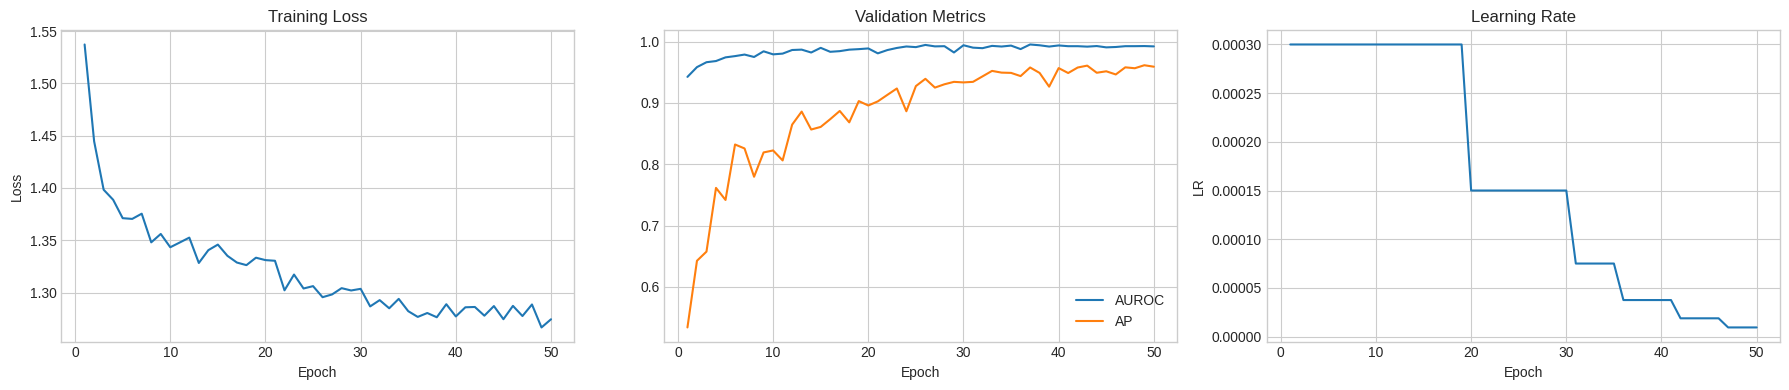

In [9]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"])
axes[0].set(xlabel="Epoch", ylabel="Loss", title="Training Loss")

axes[1].plot(hist_df["epoch"], hist_df["val_auroc"], label="AUROC")
axes[1].plot(hist_df["epoch"], hist_df["val_ap"],    label="AP")
axes[1].set(xlabel="Epoch", title="Validation Metrics"); axes[1].legend()

axes[2].plot(hist_df["epoch"], hist_df["lr"])
axes[2].set(xlabel="Epoch", ylabel="LR", title="Learning Rate")

plt.tight_layout()
plt.savefig(ARTIFACTS / "training_curves_v3.png", dpi=150)
plt.show()


## Final Evaluation

Evaluate validation and test performance with and without D4 TTA, then summarize the results.

In [11]:
print("\n" + "=" * 65)
print("FINAL EVALUATION")
print("=" * 65)

runs = {
    "Validation / no TTA": evaluate(model, val_loader),
    "Test / no TTA":       evaluate(model, test_loader),
    "Validation / D4 TTA": evaluate(model, val_loader,  tta_fn=d4_tta),
    "Test / D4 TTA":       evaluate(model, test_loader, tta_fn=d4_tta),
}

rows = []
for name, res in runs.items():
    split, setting = name.split(" / ")
    rows.append({"split": split.strip(), "setting": setting,
                 "auroc": res["auroc"], "ap": res["ap"]})

print("\nMetrics summary:")
print(pd.DataFrame(rows).round(4).to_string(index=False))

for split_key in ("Validation", "Test"):
    no_tta = runs[f"{split_key} / no TTA"]
    d4     = runs[f"{split_key} / D4 TTA"]
    print(f"  {split_key} TTA ΔAUROC={d4['auroc']-no_tta['auroc']:+.4f}  "
          f"ΔAP={d4['ap']-no_tta['ap']:+.4f}")



FINAL EVALUATION


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.50 GiB. GPU 0 has a total capacity of 7.66 GiB of which 700.81 MiB is free. Including non-PyTorch memory, this process has 6.97 GiB memory in use. Of the allocated memory 6.49 GiB is allocated by PyTorch, and 274.45 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Threshold Analysis And Curves

Compute the supplementary Youden's J threshold on the test D4-TTA predictions and plot ROC/PR curves.

In [ ]:
best_run = runs["Test / D4 TTA"]
y_true, y_prob = best_run["labels"], best_run["probs"]

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
opt_idx   = np.argmax(tpr - fpr)
opt_thr   = thresholds[opt_idx]

y_pred    = (y_prob >= opt_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nOptimal threshold (Youden's J): {opt_thr:.4f}")
print(f"  TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")
print(f"\nRecommended submission: Test D4 TTA  |  "
      f"AUROC={best_run['auroc']:.4f}  AP={best_run['ap']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

styles = [("--", "Validation / no TTA"), ("--", "Test / no TTA"),
          ("-",  "Validation / D4 TTA"), ("-",  "Test / D4 TTA")]

for ls, key in styles:
    res = runs[key]
    f, t, _ = roc_curve(res["labels"], res["probs"])
    axes[0].plot(f, t, ls, alpha=0.8, label=f"{key}  (AUC={res['auroc']:.3f})")

axes[0].scatter([fpr[opt_idx]], [tpr[opt_idx]], marker="*", s=200,
                color="red", zorder=5, label=f"Optimal θ={opt_thr:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curves")
axes[0].legend(fontsize=8)

for ls, key in styles:
    res = runs[key]
    p, r, _ = precision_recall_curve(res["labels"], res["probs"])
    axes[1].plot(r, p, ls, alpha=0.8, label=f"{key}  (AP={res['ap']:.3f})")

axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curves")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(ARTIFACTS / "roc_pr_curves_v3.png", dpi=150)
plt.show()
print(f"\nPlots saved to {ARTIFACTS}")
print("Done.")
